# 2D graphs

The 2D visualization is a topology-oriented flattening derived from the 3D vessel skeleton = projection of skeleton coordinates in 2D; it is intended to summarize connectivity and branch-wise features rather than preserve true anatomical distances or spatial relationships. 

## Straight lines

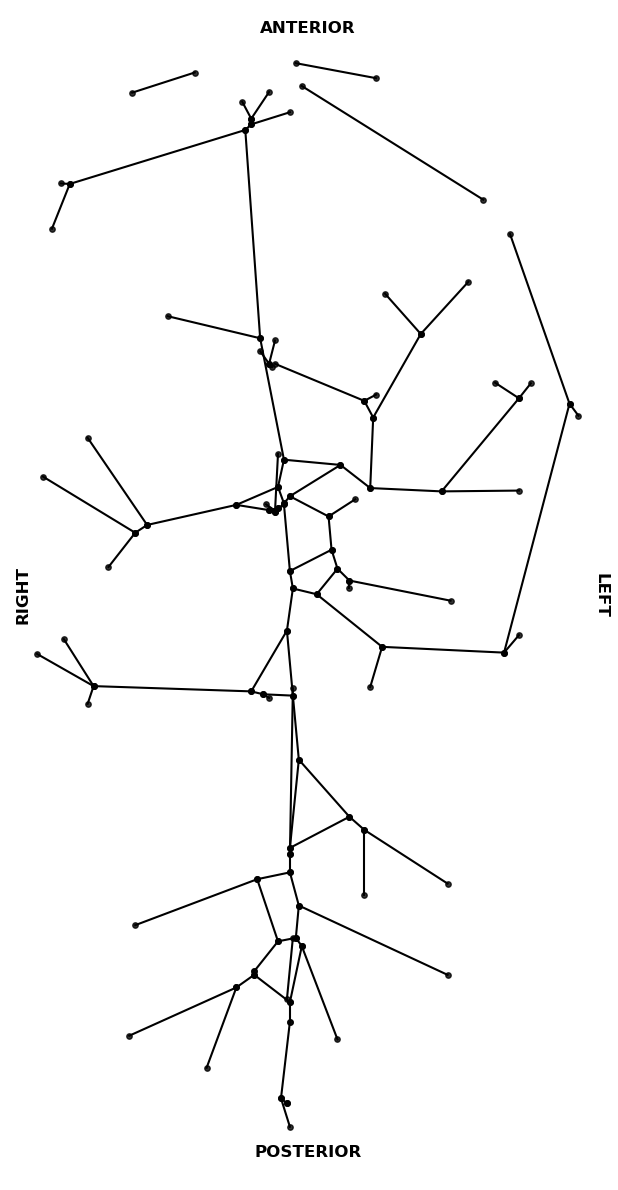

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skan import Skeleton

# 1. LOAD DATA
img_seg = nib.load('../cases/segments_unified/sub-stroke_0002_seg.nii.gz')
seg_data = img_seg.get_fdata()
zooms = np.array(img_seg.header.get_zooms()[:3])

# 2. ROBUST CENTRING
centre_mm = np.median(np.argwhere(seg_data == 6), axis=0) * zooms

# 3. SKELETON AND PLOT
mask = seg_data > 0
ske = Skeleton(skeletonize(mask))

# 4. FIGURE CONFIGURATION
fig, ax = plt.subplots(figsize=(10, 12), facecolor='white')

for i in range(ske.n_paths):
    path_vox = ske.path_coordinates(i)
    
    # Pruning: Calculate true 3D length
    diffs = np.diff(path_vox * zooms, axis=0)
    if np.sum(np.linalg.norm(diffs, axis=1)) < 1.0: # prune threshold
        continue
    
    # Projection 3D -> 2D (Vectorized subtraction)
    p_mm = (np.array([path_vox[0], path_vox[-1]]) * zooms) - centre_mm
    
    x_plot = p_mm[:, 0]
    y_plot = np.sign(p_mm[:, 1]) * np.sqrt(p_mm[:, 1]**2 + p_mm[:, 2]**2)
    
    # Plot
    ax.plot(x_plot, y_plot, color='black', linewidth=1.5, zorder=1)
    ax.scatter(x_plot, y_plot, color='black', s=15, zorder=2, alpha=0.8)

# 5. CLEANUP AND LABELS
ax.set_aspect('equal')
ax.axis('off')

# Orientation
txt_style = {'transform': ax.transAxes, 'fontweight': 'bold', 'color': 'black', 'fontsize': 12}
ax.text(0.5, 0.98, 'ANTERIOR', ha='center', **txt_style)
ax.text(0.5, 0.02, 'POSTERIOR', ha='center', **txt_style)
ax.text(0.01, 0.5, 'RIGHT', rotation=90, va='center', **txt_style)
ax.text(0.98, 0.5, 'LEFT', rotation=-90, va='center', **txt_style)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Curved lines

### Density:

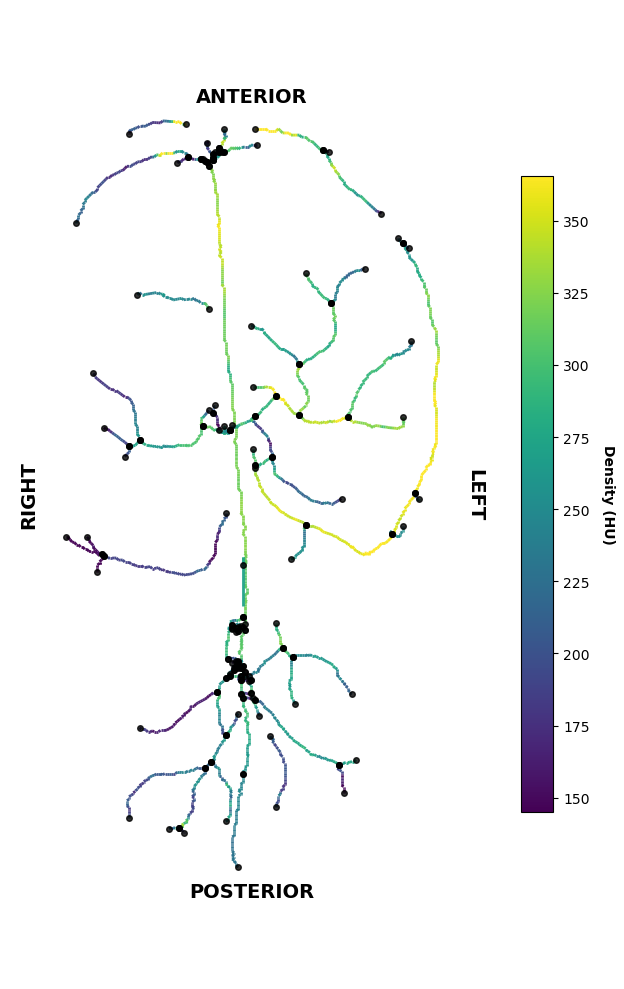

In [12]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.ndimage import distance_transform_edt
from skimage.morphology import skeletonize, remove_small_objects
from skan import Skeleton

# 1. LOAD DATA & MASKS
ct_data = nib.load("../cases/cta/sub-stroke_0002_ct.nii.gz").get_fdata()
img_seg = nib.load("../cases/segments/sub-stroke_0002_seg.nii.gz")
seg_data, zooms = img_seg.get_fdata(), np.array(img_seg.header.get_zooms()[:3], dtype=float)

target_labels = [5, 10, 11]
mask = remove_small_objects(np.isin(seg_data, target_labels), min_size=80, connectivity=3)
radius_map_mm = distance_transform_edt(mask, sampling=zooms)
centre_mm = np.median(np.argwhere(seg_data == 5), axis=0) * zooms
ske = Skeleton(skeletonize(mask))

# Pre-calculate bounds outside the loop for speed
CT_MAX_BOUNDS = np.array(ct_data.shape) - 1

# 2. HU EXTRACTION HELPER
def get_hu(path_vox):
    hu = []
    for pt in np.round(path_vox).astype(int):
        c = np.clip(pt, 0, CT_MAX_BOUNDS)
        r_mm = max(0.5, radius_map_mm[tuple(c)])
        rx, ry, rz = np.maximum(1, np.ceil(r_mm / zooms).astype(int))
        
        slc = tuple(slice(max(0, c[i] - r), min(ct_data.shape[i], c[i] + r + 1)) for i, r in enumerate((rx, ry, rz)))
        ct_p, mask_p = ct_data[slc], mask[slc]
        
        grid = np.ogrid[slc]
        dist_mm = np.sqrt(sum(((grid[i] - c[i]) * zooms[i])**2 for i in range(3)))
        
        valid = ct_p[(dist_mm <= r_mm) & mask_p]
        hu.append(np.percentile(valid, 80) if valid.size else ct_data[tuple(c)])
        
    return np.array(hu)

# 3. PROCESS PATHS
all_segs, all_hus, nodes = [], [], []

for i in range(ske.n_paths):
    path_vox = np.asarray(ske.path_coordinates(i))
    if len(path_vox) < 2: continue
    
    path_mm = path_vox * zooms
    if np.sum(np.linalg.norm(np.diff(path_mm, axis=0), axis=1)) < 2.0: continue
    
    hu_vals = get_hu(path_vox)
    
    rel = path_mm - centre_mm
    xy = np.column_stack([rel[:, 0], np.sign(rel[:, 1]) * np.hypot(rel[:, 1], rel[:, 2])])
    
    keep = np.insert(np.linalg.norm(np.diff(xy, axis=0), axis=1) > 1e-6, 0, True)
    xy, hu_vals = xy[keep], hu_vals[keep]
    if len(xy) < 2: continue
    
    segments = np.stack([xy[:-1], xy[1:]], axis=1)
    segment_hus = (hu_vals[:-1] + hu_vals[1:]) * 0.5
    
    seg_lens_2d = np.linalg.norm(segments[:, 1, :] - segments[:, 0, :], axis=1)
    valid = seg_lens_2d < 15.0 
    
    # Filter valid segments safely
    valid_segs = segments[valid]
    if len(valid_segs) == 0: continue
    
    all_segs.append(valid_segs)
    all_hus.append(segment_hus[valid])
    
    # Grab endpoints safely from surviving segments to prevent floating nodes
    nodes.extend([valid_segs[0, 0, :], valid_segs[-1, 1, :]])

# 4. PLOTTING
fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")
ax.set_aspect("equal")
ax.axis("off")

if all_segs:
    final_segs, final_hus = np.vstack(all_segs), np.concatenate(all_hus)
    norm = plt.Normalize(vmin=np.percentile(final_hus, 2), vmax=np.percentile(final_hus, 98))
    
    lc = LineCollection(final_segs, cmap="viridis", norm=norm, linewidths=2.0, zorder=1, alpha=0.95)
    lc.set_array(final_hus)
    ax.add_collection(lc)
    
    for i, set_limit in enumerate([ax.set_xlim, ax.set_ylim]):
        d_min, d_max = final_segs[..., i].min(), final_segs[..., i].max()
        pad = 0.15 * (d_max - d_min)
        set_limit(d_min - pad, d_max + pad)
    
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("Density (HU)", rotation=270, labelpad=18, fontweight="bold")

if nodes:
    nodes = np.unique(np.array(nodes), axis=0)
    ax.scatter(nodes[:, 0], nodes[:, 1], color="black", s=8, zorder=2, alpha=0.8)

txt_style = {'transform': ax.transAxes, 'fontweight': 'bold', 'color': 'black', 'fontsize': 14}
ax.text(0.5, 0.92, "ANTERIOR", ha="center", va="top", **txt_style)
ax.text(0.5, 0.08, "POSTERIOR", ha="center", va="bottom", **txt_style)
ax.text(0.02, 0.5, "RIGHT", rotation=90, va="center", ha="left", **txt_style)
ax.text(0.98, 0.5, "LEFT", rotation=-90, va="center", ha="right", **txt_style)

#ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Diameter:

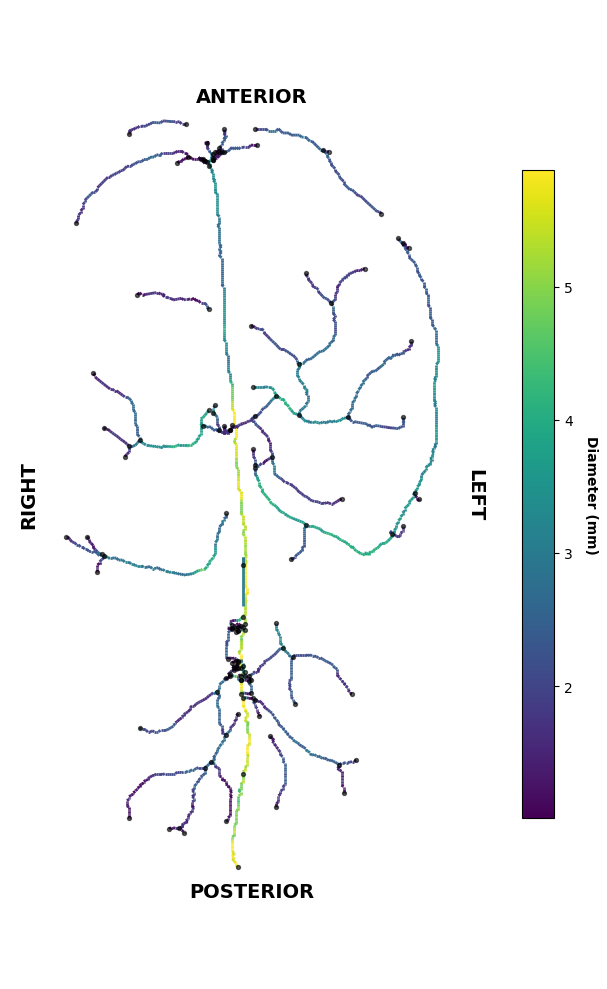

In [20]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.ndimage import map_coordinates, distance_transform_edt
from skimage.morphology import skeletonize, remove_small_objects
from skan import Skeleton

# 1. LOAD & PREPaRE DATA
img_seg = nib.load("../cases/segments/sub-stroke_0002_seg.nii.gz")
seg_data, zooms = img_seg.get_fdata(), np.array(img_seg.header.get_zooms()[:3])

target_labels = [5, 10, 11]
mask = remove_small_objects(np.isin(seg_data, target_labels), min_size=80, connectivity=3)
radius_map = distance_transform_edt(mask, sampling=zooms)
centre = np.median(np.argwhere(seg_data == 5), axis=0) * zooms

ske = Skeleton(skeletonize(mask))

# 2. PROCESS PATHS
all_segs, all_diams, nodes = [], [], []

for i in range(ske.n_paths):
    path_vox = np.asarray(ske.path_coordinates(i))
    if len(path_vox) < 2: continue
    
    path_mm = path_vox * zooms
    if np.sum(np.linalg.norm(np.diff(path_mm, axis=0), axis=1)) < 2.0: continue
    
    # Calculate exact diameter using the distance transform
    path_diams = map_coordinates(radius_map, path_vox.T, order=1, mode="nearest") * 2.0
    
    # 2D Projection
    rel = path_mm - centre
    xy = np.column_stack([rel[:, 0], np.sign(rel[:, 1]) * np.hypot(rel[:, 1], rel[:, 2])])
    
    # Remove consecutive duplicates
    keep = np.insert(np.linalg.norm(np.diff(xy, axis=0), axis=1) > 1e-6, 0, True)
    xy, path_diams = xy[keep], path_diams[keep]
    if len(xy) < 2: continue
    
    # Build segments
    segments = np.stack([xy[:-1], xy[1:]], axis=1)
    segment_diams = (path_diams[:-1] + path_diams[1:]) * 0.5
    
    # Anti-Tearing Filter
    seg_lens_2d = np.linalg.norm(segments[:, 1, :] - segments[:, 0, :], axis=1)
    valid = seg_lens_2d < 15.0 
    
    valid_segs = segments[valid]
    if len(valid_segs) == 0: 
        continue
        
    all_segs.append(valid_segs)
    all_diams.append(segment_diams[valid])
    nodes.extend([xy[0], xy[-1]]) # Track coordinates as pairs

# 3. PLOT
fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")
ax.set_aspect("equal")
ax.axis("off")

if all_segs:
    segs, diams = np.vstack(all_segs), np.concatenate(all_diams)
    norm = plt.Normalize(vmin=np.percentile(diams, 2), vmax=np.percentile(diams, 98))
    
    lc = LineCollection(segs, cmap="viridis", norm=norm, linewidths=2.0, alpha=0.95)
    lc.set_array(diams)
    ax.add_collection(lc)
    
    for i, set_limit in enumerate([ax.set_xlim, ax.set_ylim]):
        d_min, d_max = segs[..., i].min(), segs[..., i].max()
        pad = 0.15 * (d_max - d_min)
        set_limit(d_min - pad, d_max + pad)
        
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax, 
                 fraction=0.035, pad=0.03).set_label("Diameter (mm)", rotation=270, labelpad=18, fontweight="bold")

if nodes:
    nodes = np.unique(np.array(nodes), axis=0)
    ax.scatter(nodes[:, 0], nodes[:, 1], color="black", s=8, zorder=2, alpha=0.6)

txt_kw = {'transform': ax.transAxes, 'fontweight': 'bold', 'color': 'black', 'fontsize': 14}
ax.text(0.5, 0.92, "ANTERIOR", ha="center", va="top", **txt_kw)
ax.text(0.5, 0.08, "POSTERIOR", ha="center", va="bottom", **txt_kw)
ax.text(0.02, 0.5, "RIGHT", rotation=90, va="center", ha="left", **txt_kw)
ax.text(0.98, 0.5, "LEFT", rotation=-90, va="center", ha="right", **txt_kw)

#ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Tortuosity:

Statistics successfully saved to cortical_tortuosity_stats.csv


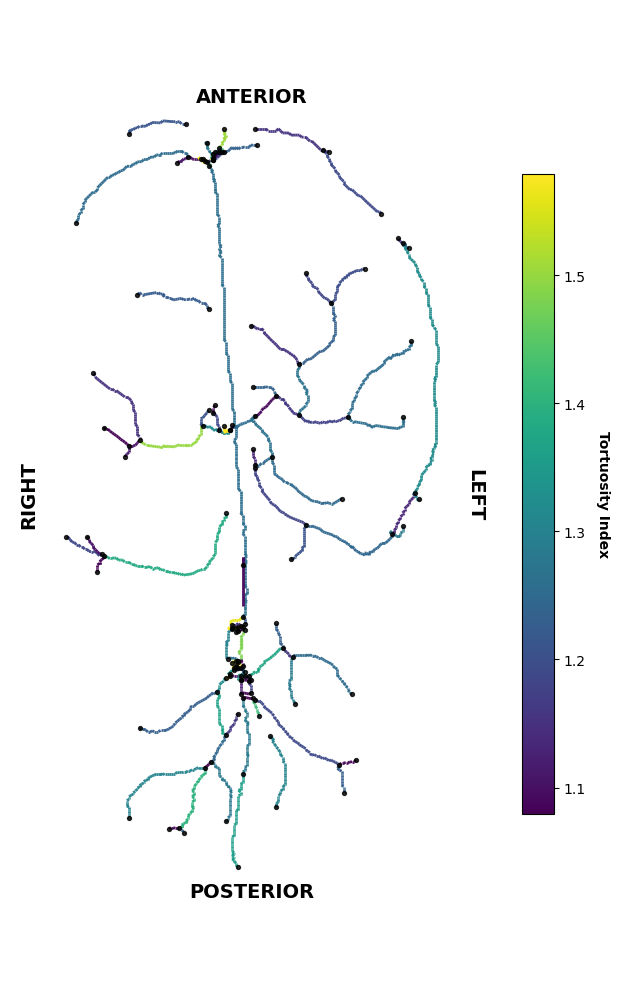

In [22]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from skimage.morphology import skeletonize, remove_small_objects
from skan import Skeleton
import csv

# 1. LOAD & PREP
img_seg = nib.load("../cases/segments/sub-stroke_0002_seg.nii.gz")
seg_data, zooms = img_seg.get_fdata(), np.array(img_seg.header.get_zooms()[:3], dtype=float)

# Masking & Skeletonization - Only include labels 5, 10, and 11
target_labels = [5, 10, 11]
mask = remove_small_objects(np.isin(seg_data, target_labels), min_size=80, connectivity=3)

# SSS is label 5
centre = np.median(np.argwhere(seg_data == 5), axis=0) * zooms

ske = Skeleton(skeletonize(mask))

# 2. PROCESS PATHS
all_segs, all_tortuosities, nodes = [], [], []
branch_tortuosities = [] 

for i in range(ske.n_paths):
    path_vox = np.asarray(ske.path_coordinates(i))
    if len(path_vox) < 2: continue
    
    path_mm = path_vox * zooms
    
    # Calculate Arc Length
    arc_length_mm = np.sum(np.linalg.norm(np.diff(path_mm, axis=0), axis=1))
    if arc_length_mm < 2.0: continue
    
    # Calculate Chord Length and Branch Tortuosity
    chord_length_mm = np.linalg.norm(path_mm[-1] - path_mm[0])
    tortuosity = arc_length_mm / chord_length_mm if chord_length_mm > 1e-6 else 1.0
    
    # 2D Projection
    rel = path_mm - centre
    xy = np.column_stack([rel[:, 0], np.sign(rel[:, 1]) * np.hypot(rel[:, 1], rel[:, 2])])
    
    keep = np.insert(np.linalg.norm(np.diff(xy, axis=0), axis=1) > 1e-6, 0, True)
    xy = xy[keep]
    if len(xy) < 2: continue
    
    # Build segments
    segments = np.stack([xy[:-1], xy[1:]], axis=1)
    
    # Anti-Tearing Filter
    seg_lens_2d = np.linalg.norm(segments[:, 1, :] - segments[:, 0, :], axis=1)
    valid = seg_lens_2d < 15.0 
    
    valid_segs = segments[valid]
    if len(valid_segs) == 0: continue
        
    all_segs.append(valid_segs)
    all_tortuosities.append(np.full(len(valid_segs), tortuosity))
    nodes.extend([valid_segs[0, 0, :], valid_segs[-1, 1, :]])
    
    # --- NEW STATS FILTERING LOGIC ---
    # Map path coordinates back to voxel integers to find their segmentation labels
    coords = np.round(path_vox).astype(int)
    path_labels = seg_data[coords[:, 0], coords[:, 1], coords[:, 2]]
    
    if len(path_labels) > 0:
        # Find the most common label along this branch
        unique_labels, counts = np.unique(path_labels, return_counts=True)
        majority_label = unique_labels[np.argmax(counts)]
        
        # Only add to the statistics list if it's NOT the Superior Sagittal Sinus (5)
        if majority_label != 5:
            branch_tortuosities.append(tortuosity)

# 3. PLOT
fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")
ax.set_aspect("equal")
ax.axis("off")

if all_segs:
    segs = np.vstack(all_segs)
    tortuosities = np.concatenate(all_tortuosities)
    
    t_min = max(1.0, np.percentile(tortuosities, 2))
    t_max = np.percentile(tortuosities, 98)
    norm = plt.Normalize(vmin=t_min, vmax=t_max)
    
    lc = LineCollection(segs, cmap="viridis", norm=norm, linewidths=2.0, alpha=0.95)
    lc.set_array(tortuosities)
    ax.add_collection(lc)
    
    for i, set_limit in enumerate([ax.set_xlim, ax.set_ylim]):
        d_min, d_max = segs[..., i].min(), segs[..., i].max()
        pad = 0.15 * (d_max - d_min)
        set_limit(d_min - pad, d_max + pad)
        
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax, 
                 fraction=0.035, pad=0.03).set_label("Tortuosity Index", rotation=270, labelpad=18, fontweight="bold")

if nodes:
    nodes = np.unique(np.array(nodes), axis=0)
    ax.scatter(nodes[:, 0], nodes[:, 1], color="black", s=8, zorder=2, alpha=0.8)

txt_kw = {'transform': ax.transAxes, 'fontweight': 'bold', 'color': 'black', 'fontsize': 14}
ax.text(0.5, 0.92, "ANTERIOR", ha="center", va="top", **txt_kw)
ax.text(0.5, 0.08, "POSTERIOR", ha="center", va="bottom", **txt_kw)
ax.text(0.02, 0.5, "RIGHT", rotation=90, va="center", ha="left", **txt_kw)
ax.text(0.98, 0.5, "LEFT", rotation=-90, va="center", ha="right", **txt_kw)

plt.tight_layout()

# 4. SAVE STATS TO CSV (Excluding Label 5)
if branch_tortuosities:
    stats = {
        "Number of Cortical Branches": len(branch_tortuosities),
        "Mean Tortuosity": np.mean(branch_tortuosities),
        "Median Tortuosity": np.median(branch_tortuosities),
        "Min Tortuosity": np.min(branch_tortuosities),
        "Max Tortuosity": np.max(branch_tortuosities),
        "Std Dev Tortuosity": np.std(branch_tortuosities)
    }
    
    csv_filename = "cortical_tortuosity_stats.csv"
    with open(csv_filename, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(stats.keys())
        writer.writerow(stats.values())
        
    print(f"Statistics successfully saved to {csv_filename}")

plt.show()

Statistics successfully saved to cortical_tortuosity_stats_v2.csv


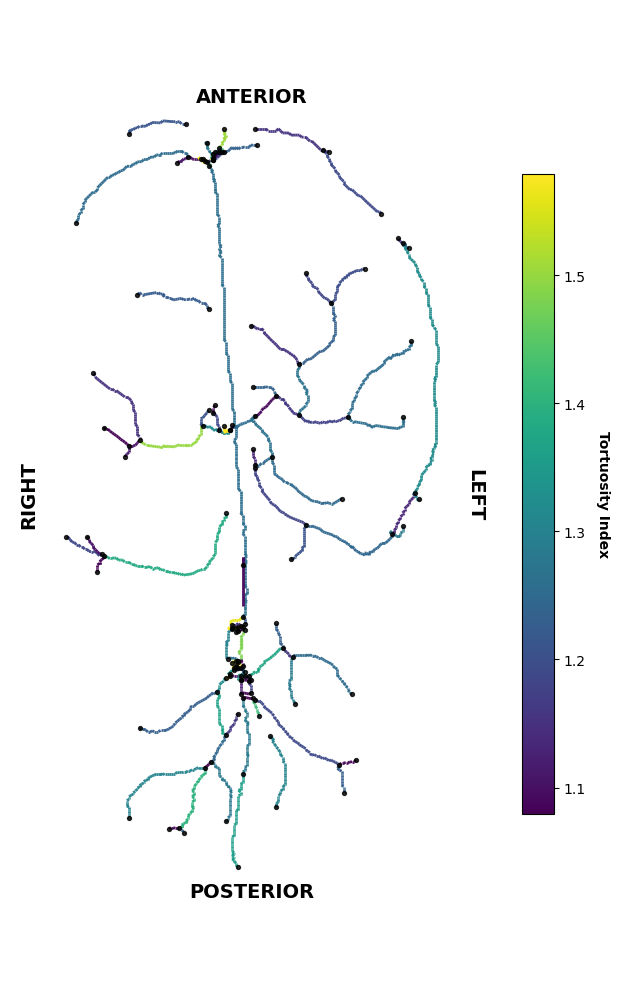

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from skimage.morphology import skeletonize, remove_small_objects
from skan import Skeleton
import csv

# ---------------------------------------------------------
# 1. LOAD & PREP
# ---------------------------------------------------------
img_seg = nib.load("../cases/segments/sub-stroke_0002_seg.nii.gz")
seg_data, zooms = img_seg.get_fdata(), np.array(img_seg.header.get_zooms()[:3], dtype=float)

# Masking: Only include labels 5 (SSS), 10 (Cortical-L), and 11 (Cortical-R)
target_labels = [5, 10, 11]
mask = remove_small_objects(np.isin(seg_data, target_labels), min_size=80, connectivity=3)

# Center based on SSS (label 5)
centre = np.median(np.argwhere(seg_data == 5), axis=0) * zooms

# Skeletonization
binary_skeleton = skeletonize(mask)

# Optional: Save the labeled skeleton as a NIfTI to view in 3D (ITK-SNAP/Slicer)
labeled_skeleton = binary_skeleton * seg_data
labeled_img = nib.Nifti1Image(labeled_skeleton, img_seg.affine, img_seg.header)
nib.save(labeled_img, "labeled_skeleton.nii.gz")

ske = Skeleton(binary_skeleton)

# ---------------------------------------------------------
# 2. PROCESS PATHS
# ---------------------------------------------------------
all_segs, all_tortuosities, nodes = [], [], []
branch_tortuosities = [] # Used for CSV stats

for i in range(ske.n_paths):
    path_vox = np.asarray(ske.path_coordinates(i))
    if len(path_vox) < 2: continue
    
    path_mm = path_vox * zooms
    
    # Calculate Arc Length (Threshold is currently 2.0mm)
    arc_length_mm = np.sum(np.linalg.norm(np.diff(path_mm, axis=0), axis=1))
    if arc_length_mm < 2.0: continue
    
    # Calculate Chord Length and Branch Tortuosity
    chord_length_mm = np.linalg.norm(path_mm[-1] - path_mm[0])
    tortuosity = arc_length_mm / chord_length_mm if chord_length_mm > 1e-6 else 1.0
    
    # 2D Projection (Oriented correctly for Anterior/Posterior)
    rel = path_mm - centre
    xy = np.column_stack([rel[:, 0], np.sign(rel[:, 1]) * np.hypot(rel[:, 1], rel[:, 2])])
    
    keep = np.insert(np.linalg.norm(np.diff(xy, axis=0), axis=1) > 1e-6, 0, True)
    xy = xy[keep]
    if len(xy) < 2: continue
    
    # Build segments
    segments = np.stack([xy[:-1], xy[1:]], axis=1)
    
    # Anti-Tearing Filter
    seg_lens_2d = np.linalg.norm(segments[:, 1, :] - segments[:, 0, :], axis=1)
    valid = seg_lens_2d < 15.0 
    
    valid_segs = segments[valid]
    if len(valid_segs) == 0: continue
        
    all_segs.append(valid_segs)
    all_tortuosities.append(np.full(len(valid_segs), tortuosity))
    nodes.extend([valid_segs[0, 0, :], valid_segs[-1, 1, :]])
    
    # --- STATS FILTERING LOGIC ---
    # Map path coordinates back to voxel integers to find their segmentation labels
    coords = np.round(path_vox).astype(int)
    path_labels = seg_data[coords[:, 0], coords[:, 1], coords[:, 2]]
    
    if len(path_labels) > 0:
        # Find the most common label along this specific branch
        unique_labels, counts = np.unique(path_labels, return_counts=True)
        majority_label = unique_labels[np.argmax(counts)]
        
        # Only add to the statistics list if it's NOT the Superior Sagittal Sinus (5)
        if majority_label != 5:
            branch_tortuosities.append(tortuosity)

# ---------------------------------------------------------
# 3. PLOT
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")
ax.set_aspect("equal")
ax.axis("off")

if all_segs:
    segs = np.vstack(all_segs)
    tortuosities = np.concatenate(all_tortuosities)
    
    t_min = max(1.0, np.percentile(tortuosities, 2))
    t_max = np.percentile(tortuosities, 98)
    norm = plt.Normalize(vmin=t_min, vmax=t_max)
    
    lc = LineCollection(segs, cmap="viridis", norm=norm, linewidths=2.0, alpha=0.95)
    lc.set_array(tortuosities)
    ax.add_collection(lc)
    
    for i, set_limit in enumerate([ax.set_xlim, ax.set_ylim]):
        d_min, d_max = segs[..., i].min(), segs[..., i].max()
        pad = 0.15 * (d_max - d_min)
        set_limit(d_min - pad, d_max + pad)
        
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax, 
                 fraction=0.035, pad=0.03).set_label("Tortuosity Index", rotation=270, labelpad=18, fontweight="bold")

if nodes:
    # Use np.unique to prevent black dot stacking/clutter at junctions
    nodes = np.unique(np.array(nodes), axis=0)
    ax.scatter(nodes[:, 0], nodes[:, 1], color="black", s=8, zorder=2, alpha=0.8)

txt_kw = {'transform': ax.transAxes, 'fontweight': 'bold', 'color': 'black', 'fontsize': 14}
ax.text(0.5, 0.92, "ANTERIOR", ha="center", va="top", **txt_kw)
ax.text(0.5, 0.08, "POSTERIOR", ha="center", va="bottom", **txt_kw)
ax.text(0.02, 0.5, "RIGHT", rotation=90, va="center", ha="left", **txt_kw)
ax.text(0.98, 0.5, "LEFT", rotation=-90, va="center", ha="right", **txt_kw)

plt.tight_layout()

# ---------------------------------------------------------
# 4. SAVE STATS TO CSV
# ---------------------------------------------------------
if branch_tortuosities:
    stats = {
        "Number of Cortical Branches": len(branch_tortuosities),
        "Mean Tortuosity": np.mean(branch_tortuosities),
        "Median Tortuosity": np.median(branch_tortuosities),
        "Min Tortuosity": np.min(branch_tortuosities),
        "Max Tortuosity": np.max(branch_tortuosities),
        "Std Dev Tortuosity": np.std(branch_tortuosities)
    }
    
    csv_filename = "cortical_tortuosity_stats_v2.csv"
    with open(csv_filename, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(stats.keys())
        writer.writerow(stats.values())
        
    print(f"Statistics successfully saved to {csv_filename}")

plt.show()